In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Step 2: Load MNIST dataset
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

In [5]:
# Step 3: Preprocess images
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5 # Normalize to [-1, 1]
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

In [7]:
# Step 4: Training parameters
batch_size = 64
noise_dim = 100
epochs = 10

In [9]:
# Step 5: Create dataset
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(batch_size)


In [11]:
# Step 6: Build Generator
generator = keras.Sequential([
    keras.layers.Input(shape=(noise_dim,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(28 * 28 * 1, activation='tanh'),
    keras.layers.Reshape((28, 28, 1))
])

generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │         101,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Step 7: Build Discriminator
discriminator = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [15]:
# Step 8: Loss and Optimizers
loss_fn = keras.losses.BinaryCrossentropy()

g_optimizer = keras.optimizers.Adam(learning_rate=0.0002)
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002)


In [17]:
# Step 9: Training Loop
for epoch in range(epochs):
    for real_images in dataset:

        batch_size_now = real_images.shape[0]

        real_labels = tf.ones((batch_size_now, 1))
        fake_labels = tf.zeros((batch_size_now, 1))

        noise = tf.random.normal((batch_size_now, noise_dim))
        fake_images = generator(noise, training=True)

        # ---- Train Discriminator ----
        with tf.GradientTape() as tape:
            real_op = discriminator(real_images, training=True)
            fake_op = discriminator(fake_images, training=True)

            real_loss = loss_fn(real_labels, real_op)
            fake_loss = loss_fn(fake_labels, fake_op)

            d_loss = real_loss + fake_loss

        d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

        # ---- Train Generator ----
        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:
            generated_images = generator(noise, training=True)
            op = discriminator(generated_images, training=True)

            g_loss = loss_fn(real_labels, op)

        g_gradients = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))

    print(f"Epoch {epoch+1} | D Loss: {d_loss.numpy():.4f} | G Loss: {g_loss.numpy():.4f}")

Epoch 1 | D Loss: 0.5312 | G Loss: 1.5360
Epoch 2 | D Loss: 0.6062 | G Loss: 1.3959
Epoch 3 | D Loss: 0.6878 | G Loss: 1.5582
Epoch 4 | D Loss: 0.7931 | G Loss: 1.2505
Epoch 5 | D Loss: 0.6288 | G Loss: 1.7262
Epoch 6 | D Loss: 1.0337 | G Loss: 1.3573
Epoch 7 | D Loss: 0.4781 | G Loss: 1.9920
Epoch 8 | D Loss: 0.8175 | G Loss: 1.3068
Epoch 9 | D Loss: 0.4585 | G Loss: 2.3910
Epoch 10 | D Loss: 0.8802 | G Loss: 1.7016


In [19]:
# Step 10: Generate Images
noise = tf.random.normal((16, noise_dim))
generated_images = generator(noise, training=False)


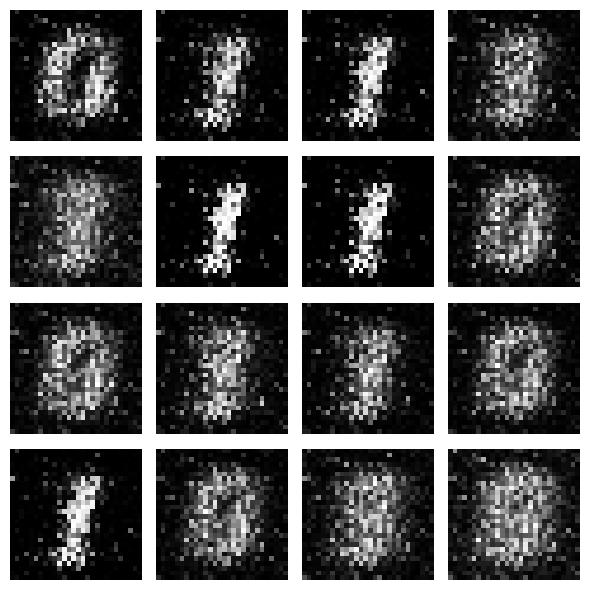

In [21]:
# Step 11: Display Images
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i, :, :, 0], cmap='gray')
    ax.axis("off")

plt.tight_layout()
plt.show()